# NB01 — Dataset Preparation

Pipeline persiapan dataset buah untuk sistem kuis CVD (Color Vision Deficiency).

**Alur tahapan:**
1. **1A** — Inventarisasi dataset raw
2. **1B** — Filter per kelas (keep / exclude berdasarkan relevansi hue)
3. **1C** — Deduplikasi perceptual hash (pHash) per kelas yang di-keep
4. **1D** — Stratified split → `fruit_split/train`, `val`, `test`
5. **1E** — Summary & ekspor metadata

**Output:** `processed/fruit_split/` — siap diproses NB02 (filter per individu + hue extraction)

> Notebook ini **tidak melakukan filter warna per gambar** — itu tanggung jawab NB02.


In [1]:
%pip install opencv-python-headless numpy pillow imagehash pandas matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import datetime
import json
import math
import random
import shutil
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image

RANDOM_SEED: int = 42

RESEARCH_ROOT  = Path(r"C:\Colorblind_correction\research")
RAW_FRUITS_DIR = RESEARCH_ROOT / "datasets" / "raw" / "fruits"
PROCESSED_DIR  = RESEARCH_ROOT / "datasets" / "processed"
SPLIT_DIR      = PROCESSED_DIR / "fruit_split"   # output NB01
EXPORTS_DIR    = RESEARCH_ROOT / "notebooks" / "01" / "output"

EXPORTS_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

# Val diambil dari train raw (fixed-per-class strategy).
# Floor & ceiling menjaga kelas kecil tetap dapat val yang cukup, kelas besar tidak terkuras.
VAL_RATIO        : float = 0.15
VAL_MIN_PER_CLASS: int   = 15
VAL_MAX_PER_CLASS: int   = 30

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# Exclude: bukan buah, atau warna ambigu/tidak relevan untuk diagnosis CVD.
EXCLUDED_CLASSES = {
    "000neg",     # negative samples, bukan buah
    "008kiwi",    # coklat berbulu luar, ambigu hijau-coklat
    "013grape",   # ambigu: ada ungu dan hijau dalam satu kelas
    "017durian",  # kuning-hijau ambigu, kulit berduri dominan
}

print("[INIT] Konfigurasi pipeline NB01:")
print(f"  RAW_FRUITS_DIR   : {RAW_FRUITS_DIR}")
print(f"  SPLIT_DIR        : {SPLIT_DIR}")
print(f"  EXPORTS_DIR      : {EXPORTS_DIR}")
print(f"  RANDOM_SEED      : {RANDOM_SEED}")
print(f"  VAL_RATIO        : {VAL_RATIO:.0%}")
print(f"  VAL_MIN_PER_CLASS: {VAL_MIN_PER_CLASS}")
print(f"  VAL_MAX_PER_CLASS: {VAL_MAX_PER_CLASS}")
print(f"  EXCLUDED_CLASSES : {sorted(EXCLUDED_CLASSES)}")


[INIT] Konfigurasi pipeline NB01:
  RAW_FRUITS_DIR   : C:\Colorblind_correction\research\datasets\raw\fruits
  SPLIT_DIR        : C:\Colorblind_correction\research\datasets\processed\fruit_split
  EXPORTS_DIR      : C:\Colorblind_correction\research\notebooks\01\output
  RANDOM_SEED      : 42
  VAL_RATIO        : 15%
  VAL_MIN_PER_CLASS: 15
  VAL_MAX_PER_CLASS: 30
  EXCLUDED_CLASSES : ['000neg', '008kiwi', '013grape', '017durian']


## Tahap 1A — Inventarisasi Dataset Raw

Scan seluruh folder kelas di `raw/fruits/` dan hitung jumlah gambar train & test per kelas.


In [3]:
def scan_raw_dataset(raw_dir: Path, valid_ext: set) -> pd.DataFrame:
    """Scan folder raw, kembalikan inventaris jumlah gambar train/test per kelas."""
    rows = []
    for class_dir in sorted(raw_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        train_count = sum(
            1 for f in (class_dir / "train").iterdir()
            if f.is_file() and f.suffix.lower() in valid_ext
        ) if (class_dir / "train").exists() else 0

        test_count = sum(
            1 for f in (class_dir / "test").iterdir()
            if f.is_file() and f.suffix.lower() in valid_ext
        ) if (class_dir / "test").exists() else 0

        rows.append({
            "folder_name" : class_dir.name,
            "class_name"  : class_dir.name[3:],   # strip prefix angka (001, 002, dst)
            "train_count" : train_count,
            "test_count"  : test_count,
            "total_count" : train_count + test_count,
        })

    return pd.DataFrame(rows)


print("[TAHAP 1A] Memulai inventarisasi dataset raw...")
df_inventory = scan_raw_dataset(RAW_FRUITS_DIR, VALID_EXTENSIONS)

print(f"\n  Total kelas ditemukan : {len(df_inventory)}")
print(f"  Total gambar          : {df_inventory['total_count'].sum():,}")
print(f"  Total train           : {df_inventory['train_count'].sum():,}")
print(f"  Total test            : {df_inventory['test_count'].sum():,}")
print()
print(df_inventory.to_string(index=False))


[TAHAP 1A] Memulai inventarisasi dataset raw...



  Total kelas ditemukan : 19
  Total gambar          : 5,475
  Total train           : 4,603
  Total test            : 872

   folder_name  class_name  train_count  test_count  total_count
      001apple       apple          408          47          455
     002orange      orange          431          50          481
       003pear        pear          261          47          308
     004tomato      tomato          411          49          460
 005strawberry  strawberry          442          50          492
     006banana      banana          386          47          433
 007watermelon  watermelon          239          50          289
       008kiwi        kiwi          311          50          361
      009peach       peach          320          40          360
010pomegranate pomegranate          207          15          222
  011pineapple   pineapple          193          46          239
  012starfruit   starfruit          152          49          201
      013grape       grape    

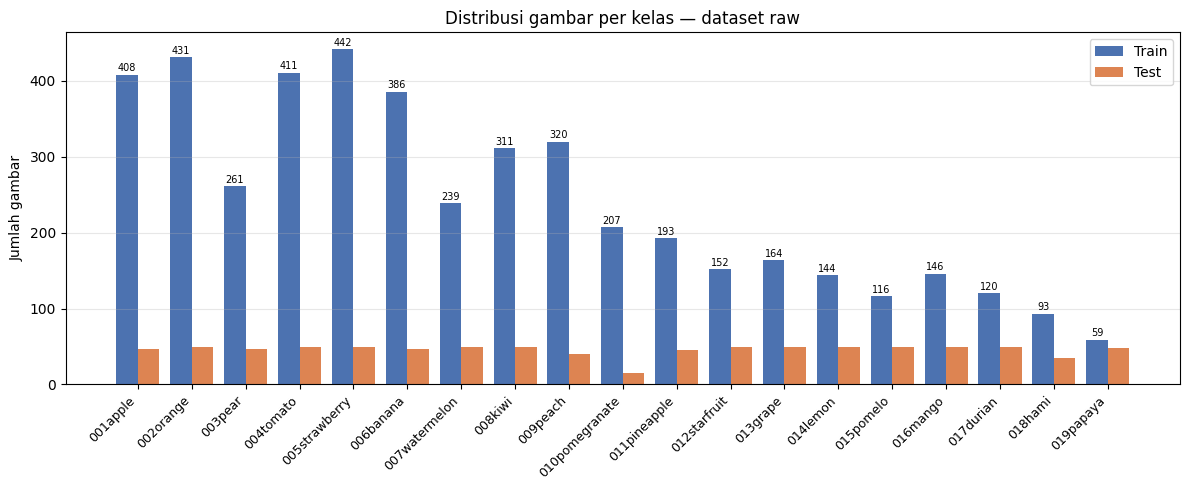

[1A] Imbalance ratio train: 7.5x (max=442, min=59)


In [4]:
# Tahap 1A: Visualisasi distribusi per kelas
fig, ax = plt.subplots(figsize=(12, 5))

x     = range(len(df_inventory))
width = 0.4

bars_tr = ax.bar(
    [i - width / 2 for i in x],
    df_inventory["train_count"],
    width=width, label="Train", color="#4C72B0"
)
bars_te = ax.bar(
    [i + width / 2 for i in x],
    df_inventory["test_count"],
    width=width, label="Test", color="#DD8452"
)

ax.set_xticks(list(x))
ax.set_xticklabels(df_inventory["folder_name"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Jumlah gambar")
ax.set_title("Distribusi gambar per kelas — dataset raw")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars_tr:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()
print(f"[1A] Imbalance ratio train: "
      f"{df_inventory['train_count'].max() / df_inventory['train_count'].min():.1f}x "
      f"(max={df_inventory['train_count'].max()}, min={df_inventory['train_count'].min()})")


## Tahap 1B — Filter Per Kelas

Tentukan kelas mana yang di-keep dan mana yang di-exclude dari pipeline.

Kriteria exclude:
- Kelas `000neg` (bukan buah)
- Warna dominan kelas ambigu (ada dua hue range berbeda dalam satu kelas)
- Warna tidak relevan untuk diagnosis CVD (protanopia / deuteranopia)

> **Catatan:** `class_hue_mapping.json` di tahap ini hanya mencatat keputusan keep/exclude.
> Klasifikasi `red_orange` vs `green_yellow` dilakukan otomatis di NB02 berdasarkan
> hasil K-Means per gambar.


In [5]:
def build_class_filter(df_inventory: pd.DataFrame, excluded_classes: set) -> pd.DataFrame:
    """Tandai setiap kelas sebagai keep atau exclude."""
    df = df_inventory.copy()
    df["action"]         = "keep"
    df["exclude_reason"] = ""

    for idx, row in df.iterrows():
        if row["folder_name"] in excluded_classes:
            df.at[idx, "action"]         = "exclude"
            df.at[idx, "exclude_reason"] = (
                "negative samples" if row["folder_name"] == "000neg"
                else "warna ambigu / tidak relevan CVD"
            )

    return df


print("[TAHAP 1B] Menerapkan filter per kelas...")
df_filter = build_class_filter(df_inventory, EXCLUDED_CLASSES)

df_kept     = df_filter[df_filter["action"] == "keep"]
df_excluded = df_filter[df_filter["action"] == "exclude"]

print(f"\n  Kelas di-keep    : {len(df_kept)}")
print(f"  Kelas di-exclude : {len(df_excluded)}")
print()

if not df_excluded.empty:
    print("  Kelas yang di-exclude:")
    for _, row in df_excluded.iterrows():
        print(f"    - {row['folder_name']:<20} alasan: {row['exclude_reason']}")

print()
print("  Kelas yang di-keep:")
print(f"  {'Folder':<20} {'Class':<15} {'Train':>6} {'Test':>6} {'Total':>7}")
print(f"  {'-'*20} {'-'*15} {'-'*6} {'-'*6} {'-'*7}")
for _, row in df_kept.iterrows():
    print(
        f"  {row['folder_name']:<20} {row['class_name']:<15}"
        f" {row['train_count']:>6} {row['test_count']:>6} {row['total_count']:>7}"
    )

class_filter_export = df_filter[[
    "folder_name", "class_name", "action", "exclude_reason"
]].to_dict(orient="records")

with open(EXPORTS_DIR / "class_filter_mapping.json", "w", encoding="utf-8") as f:
    json.dump(class_filter_export, f, indent=2, ensure_ascii=False)

print(f"\n[1B] Ekspor: {EXPORTS_DIR / 'class_filter_mapping.json'}")


[TAHAP 1B] Menerapkan filter per kelas...

  Kelas di-keep    : 16
  Kelas di-exclude : 3

  Kelas yang di-exclude:
    - 008kiwi              alasan: warna ambigu / tidak relevan CVD
    - 013grape             alasan: warna ambigu / tidak relevan CVD
    - 017durian            alasan: warna ambigu / tidak relevan CVD

  Kelas yang di-keep:
  Folder               Class            Train   Test   Total
  -------------------- --------------- ------ ------ -------
  001apple             apple              408     47     455
  002orange            orange             431     50     481
  003pear              pear               261     47     308
  004tomato            tomato             411     49     460
  005strawberry        strawberry         442     50     492
  006banana            banana             386     47     433
  007watermelon        watermelon         239     50     289
  009peach             peach              320     40     360
  010pomegranate       pomegranate        207  

## Tahap 1C — Deduplikasi (pHash)

Deteksi gambar duplikat menggunakan perceptual hash (pHash) per kelas yang di-keep.
Dua gambar dianggap duplikat jika jarak Hamming hash-nya ≤ threshold.

Deduplikasi dilakukan **sebelum split** agar tidak ada gambar yang sama
masuk ke train dan val sekaligus.


In [ ]:
PHASH_THRESHOLD: int = 8   # jarak Hamming maksimum — 0=identik, >10=berbeda

def compute_phash(image_path: Path) -> imagehash.ImageHash | None:
    """Hitung perceptual hash gambar, None jika gagal dibaca."""
    try:
        with Image.open(image_path) as img:
            return imagehash.phash(img)
    except Exception:
        return None


def find_duplicates(
    image_paths: list[Path],
    threshold: int = PHASH_THRESHOLD,
) -> tuple[set[Path], list[dict]]:
    """Temukan duplikat dalam satu kelas via pHash.

    Strategi: simpan gambar pertama tiap grup duplikat, tandai sisanya untuk dibuang.
    """
    hash_registry: list[tuple[imagehash.ImageHash, Path]] = []
    duplicates   : set[Path]  = set()
    log          : list[dict] = []

    for path in image_paths:
        h = compute_phash(path)
        if h is None:
            continue

        matched = False
        for existing_hash, existing_path in hash_registry:
            if abs(h - existing_hash) <= threshold:
                duplicates.add(path)
                log.append({
                    "duplicate" : str(path),
                    "similar_to": str(existing_path),
                    "distance"  : int(abs(h - existing_hash)),
                })
                matched = True
                break

        if not matched:
            hash_registry.append((h, path))

    return duplicates, log


print(f"[TAHAP 1C] Siap jalankan deduplikasi.")
print(f"  pHash threshold : {PHASH_THRESHOLD} (jarak Hamming)")
print(f"  Kelas yang akan diproses: {len(df_kept)}")


[TAHAP 1C] Siap jalankan deduplikasi.
  pHash threshold : 8 (jarak Hamming)
  Kelas yang akan diproses: 16


In [7]:
# Dedup mencakup train+test sekaligus per kelas, supaya tidak ada gambar
# yang sama lolos ke dua subset berbeda.

print("[TAHAP 1C] Menjalankan deduplikasi pHash...")
print()

all_dedup_log  : list[dict] = []
dedup_summary  : list[dict] = []
all_kept_paths : dict[str, dict[str, list[Path]]] = {}   # {folder_name: {"train": [...], "test": [...]}}

for _, row in df_kept.iterrows():
    folder_name = row["folder_name"]
    class_dir   = RAW_FRUITS_DIR / folder_name

    train_paths = sorted([
        f for f in (class_dir / "train").iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    ]) if (class_dir / "train").exists() else []

    test_paths = sorted([
        f for f in (class_dir / "test").iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    ]) if (class_dir / "test").exists() else []

    all_paths       = train_paths + test_paths
    duplicates, log = find_duplicates(all_paths, PHASH_THRESHOLD)

    clean_train = [p for p in train_paths if p not in duplicates]
    clean_test  = [p for p in test_paths  if p not in duplicates]

    all_kept_paths[folder_name] = {"train": clean_train, "test": clean_test}
    all_dedup_log.extend(log)

    removed = len(duplicates)
    dedup_summary.append({
        "folder_name" : folder_name,
        "train_before": len(train_paths),
        "test_before" : len(test_paths),
        "removed"     : removed,
        "train_after" : len(clean_train),
        "test_after"  : len(clean_test),
    })

    status = f"removed {removed}" if removed > 0 else "no duplicates"
    print(f"  {folder_name:<20} train={len(clean_train):>3}  test={len(clean_test):>3}  [{status}]")

df_dedup = pd.DataFrame(dedup_summary)
total_removed = df_dedup["removed"].sum()

print()
print(f"[1C] Total duplikat ditemukan dan dihapus: {total_removed}")
print(f"[1C] Total gambar tersisa (train+test)    : "
      f"{(df_dedup['train_after'] + df_dedup['test_after']).sum():,}")

with open(EXPORTS_DIR / "deduplication_log.json", "w", encoding="utf-8") as f:
    json.dump(all_dedup_log, f, indent=2, ensure_ascii=False)
print(f"[1C] Ekspor log: {EXPORTS_DIR / 'deduplication_log.json'}")


[TAHAP 1C] Menjalankan deduplikasi pHash...

  001apple             train=362  test= 41  [removed 52]
  002orange            train=411  test= 47  [removed 23]
  003pear              train=235  test= 43  [removed 30]
  004tomato            train=387  test= 33  [removed 40]
  005strawberry        train=415  test= 46  [removed 31]
  006banana            train=328  test= 35  [removed 70]
  007watermelon        train=211  test= 41  [removed 37]
  009peach             train=272  test= 36  [removed 52]
  010pomegranate       train=197  test= 13  [removed 12]
  011pineapple         train=178  test= 37  [removed 24]
  012starfruit         train=143  test= 40  [removed 18]
  014lemon             train=129  test= 35  [removed 30]
  015pomelo            train=104  test= 41  [removed 20]
  016mango             train=133  test= 32  [removed 31]
  018hami              train= 88  test= 31  [removed 9]
  019papaya            train= 55  test= 33  [removed 19]

[1C] Total duplikat ditemukan dan dihapus: 

## Tahap 1D — Stratified Split

Buat val set dari train raw menggunakan **fixed-per-class strategy**:

```
val_count = clamp(floor(train_count × VAL_RATIO), VAL_MIN, VAL_MAX)
```

- Kelas kecil dijamin minimal `VAL_MIN_PER_CLASS` gambar di val
- Kelas besar tidak membuang terlalu banyak ke val (dibatasi `VAL_MAX_PER_CLASS`)
- Test set dari raw **tidak disentuh** — dipertahankan apa adanya

Output disalin ke `fruit_split/train/`, `fruit_split/val/`, `fruit_split/test/`.


In [8]:
def compute_val_count(
    train_count : int,
    val_ratio   : float = VAL_RATIO,
    val_min     : int   = VAL_MIN_PER_CLASS,
    val_max     : int   = VAL_MAX_PER_CLASS,
) -> int:
    """Hitung jumlah gambar val: clamp(floor(train_count x val_ratio), val_min, val_max)."""
    raw_val = math.floor(train_count * val_ratio)
    return max(val_min, min(val_max, raw_val))


print("[TAHAP 1D] Menghitung rencana split...")
print(f"  Strategi: clamp(floor(n × {VAL_RATIO:.0%}), {VAL_MIN_PER_CLASS}, {VAL_MAX_PER_CLASS})")
print()

split_plan : list[dict] = []

for _, row in df_dedup.iterrows():
    folder_name = row["folder_name"]
    train_after = row["train_after"]
    test_after  = row["test_after"]

    val_count = compute_val_count(train_after)
    new_train = train_after - val_count

    split_plan.append({
        "folder_name"      : folder_name,
        "train_raw"        : train_after,
        "val_count"        : val_count,
        "new_train_count"  : new_train,
        "test_count"       : test_after,
        "val_ratio_actual" : round(val_count / train_after, 3) if train_after > 0 else 0,
    })

df_split = pd.DataFrame(split_plan)

print(f"  {'Folder':<20} {'Train raw':>9} {'→ Val':>6} {'→ Train':>8} {'Test':>6} {'Val%':>6}")
print(f"  {'-'*20} {'-'*9} {'-'*6} {'-'*8} {'-'*6} {'-'*6}")
for _, row in df_split.iterrows():
    print(
        f"  {row['folder_name']:<20}"
        f" {row['train_raw']:>9}"
        f" {row['val_count']:>6}"
        f" {row['new_train_count']:>8}"
        f" {row['test_count']:>6}"
        f" {row['val_ratio_actual']:>5.1%}"
    )

print()
print(f"  Total → train : {df_split['new_train_count'].sum():,}")
print(f"  Total → val   : {df_split['val_count'].sum():,}")
print(f"  Total → test  : {df_split['test_count'].sum():,}")
print(f"  Grand total   : {df_split[['new_train_count','val_count','test_count']].sum().sum():,}")


[TAHAP 1D] Menghitung rencana split...
  Strategi: clamp(floor(n × 15%), 15, 30)

  Folder               Train raw  → Val  → Train   Test   Val%
  -------------------- --------- ------ -------- ------ ------
  001apple                   362     30      332     41  8.3%
  002orange                  411     30      381     47  7.3%
  003pear                    235     30      205     43 12.8%
  004tomato                  387     30      357     33  7.8%
  005strawberry              415     30      385     46  7.2%
  006banana                  328     30      298     35  9.1%
  007watermelon              211     30      181     41 14.2%
  009peach                   272     30      242     36 11.0%
  010pomegranate             197     29      168     13 14.7%
  011pineapple               178     26      152     37 14.6%
  012starfruit               143     21      122     40 14.7%
  014lemon                   129     19      110     35 14.7%
  015pomelo                  104     15       89

In [9]:
# Tahap 1D: Eksekusi copy ke fruit_split/
def copy_split(
    all_kept_paths : dict[str, dict[str, list[Path]]],
    df_split       : pd.DataFrame,
    split_dir      : Path,
    random_seed    : int = RANDOM_SEED,
) -> dict:
    """Salin gambar ke fruit_split/train, val, test sesuai rencana split.

    Val diambil acak (stratified per kelas) dari train raw; test disalin
    langsung tanpa modifikasi. Nama file diprefix nama kelas agar tidak collision.
    """
    rng   = random.Random(random_seed)
    stats : dict = {"per_class": {}, "totals": {"train": 0, "val": 0, "test": 0}}

    for _, row in df_split.iterrows():
        folder_name = row["folder_name"]
        class_name  = folder_name[3:]   # strip prefix angka
        val_count   = row["val_count"]

        train_paths = list(all_kept_paths[folder_name]["train"])
        test_paths  = list(all_kept_paths[folder_name]["test"])

        # Shuffle dulu supaya split val tidak bias urutan file
        rng.shuffle(train_paths)
        val_paths       = train_paths[:val_count]
        new_train_paths = train_paths[val_count:]

        class_stats: dict = {"train": 0, "val": 0, "test": 0, "errors": []}

        for subset, paths in [
            ("train", new_train_paths),
            ("val",   val_paths),
            ("test",  test_paths),
        ]:
            dst_dir = split_dir / subset / folder_name
            dst_dir.mkdir(parents=True, exist_ok=True)

            for src_path in paths:
                dst_name = f"{class_name}_{src_path.name}"   # prefix kelas, hindari collision nama file
                dst_path = dst_dir / dst_name
                try:
                    shutil.copy2(src_path, dst_path)
                    class_stats[subset] += 1
                    stats["totals"][subset] += 1
                except Exception as e:
                    class_stats["errors"].append(f"{subset}/{src_path.name}: {e}")

        stats["per_class"][folder_name] = class_stats

        print(
            f"  {folder_name:<20}  "
            f"train={class_stats['train']:>3}  "
            f"val={class_stats['val']:>3}  "
            f"test={class_stats['test']:>3}"
            + (f"  ⚠ {len(class_stats['errors'])} error" if class_stats["errors"] else "")
        )

    return stats


print("[TAHAP 1D] Menyalin gambar ke fruit_split/...")
print(f"  Destination: {SPLIT_DIR}")
print()

copy_stats = copy_split(all_kept_paths, df_split, SPLIT_DIR, RANDOM_SEED)

print()
print("[1D] Ringkasan copy:")
print(f"  Train : {copy_stats['totals']['train']:,} gambar")
print(f"  Val   : {copy_stats['totals']['val']:,} gambar")
print(f"  Test  : {copy_stats['totals']['test']:,} gambar")
print(f"  Total : {sum(copy_stats['totals'].values()):,} gambar")

all_errors = [
    err
    for cls_stat in copy_stats["per_class"].values()
    for err in cls_stat["errors"]
]
if all_errors:
    print(f"\n  ⚠ Total error: {len(all_errors)}")
    for err in all_errors[:10]:
        print(f"    - {err}")
else:
    print("\n  Tidak ada error.")


[TAHAP 1D] Menyalin gambar ke fruit_split/...
  Destination: C:\Colorblind_correction\research\datasets\processed\fruit_split



  001apple              train=332  val= 30  test= 41
  002orange             train=381  val= 30  test= 47
  003pear               train=205  val= 30  test= 43
  004tomato             train=357  val= 30  test= 33
  005strawberry         train=385  val= 30  test= 46
  006banana             train=298  val= 30  test= 35
  007watermelon         train=181  val= 30  test= 41
  009peach              train=242  val= 30  test= 36
  010pomegranate        train=168  val= 29  test= 13
  011pineapple          train=152  val= 26  test= 37
  012starfruit          train=122  val= 21  test= 40
  014lemon              train=110  val= 19  test= 35
  015pomelo             train= 89  val= 15  test= 41
  016mango              train=114  val= 19  test= 32
  018hami               train= 73  val= 15  test= 31
  019papaya             train= 40  val= 15  test= 33

[1D] Ringkasan copy:
  Train : 3,249 gambar
  Val   : 399 gambar
  Test  : 584 gambar
  Total : 4,232 gambar

  Tidak ada error.


## Tahap 1E — Verifikasi & Ekspor Summary

Verifikasi struktur `fruit_split/` dan ekspor metadata pipeline untuk referensi NB02.


In [10]:
print("[TAHAP 1E] Verifikasi struktur fruit_split/...")
print()

verification_rows: list[dict] = []

for subset in ["train", "val", "test"]:
    subset_dir = SPLIT_DIR / subset
    if not subset_dir.exists():
        print(f"  ⚠ Folder tidak ada: {subset_dir}")
        continue

    for class_dir in sorted(subset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        count = sum(
            1 for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
        )
        verification_rows.append({
            "subset"     : subset,
            "folder_name": class_dir.name,
            "count"      : count,
        })

df_verify = pd.DataFrame(verification_rows)

df_pivot = df_verify.pivot(index="folder_name", columns="subset", values="count").fillna(0).astype(int)
df_pivot["total"] = df_pivot.sum(axis=1)

print(df_pivot.to_string())
print()
print(f"  Grand total verifikasi:")
for col in ["train", "val", "test", "total"]:
    if col in df_pivot.columns:
        print(f"    {col:<8}: {df_pivot[col].sum():,}")

# Cek jumlah aktual vs rencana split — harus sama persis
print()
print("  Cek konsistensi dengan rencana split:")
plan_train = df_split["new_train_count"].sum()
plan_val   = df_split["val_count"].sum()
plan_test  = df_split["test_count"].sum()
act_train  = df_pivot.get("train", pd.Series([0])).sum()
act_val    = df_pivot.get("val",   pd.Series([0])).sum()
act_test   = df_pivot.get("test",  pd.Series([0])).sum()

for subset, plan, actual in [("train", plan_train, act_train),
                               ("val",   plan_val,   act_val),
                               ("test",  plan_test,  act_test)]:
    status = "✓" if plan == actual else f"✗ expected {plan}"
    print(f"    {subset:<8}: {actual:,}  [{status}]")


[TAHAP 1E] Verifikasi struktur fruit_split/...

subset          test  train  val  total
folder_name                            
001apple          41    332   30    403
002orange         47    381   30    458
003pear           43    205   30    278
004tomato         33    357   30    420
005strawberry     46    385   30    461
006banana         35    298   30    363
007watermelon     41    181   30    252
009peach          36    242   30    308
010pomegranate    13    168   29    210
011pineapple      37    152   26    215
012starfruit      40    122   21    183
014lemon          35    110   19    164
015pomelo         41     89   15    145
016mango          32    114   19    165
018hami           31     73   15    119
019papaya         33     40   15     88

  Grand total verifikasi:
    train   : 3,249
    val     : 399
    test    : 584
    total   : 4,232

  Cek konsistensi dengan rencana split:
    train   : 3,249  [✓]
    val     : 399  [✓]
    test    : 584  [✓]


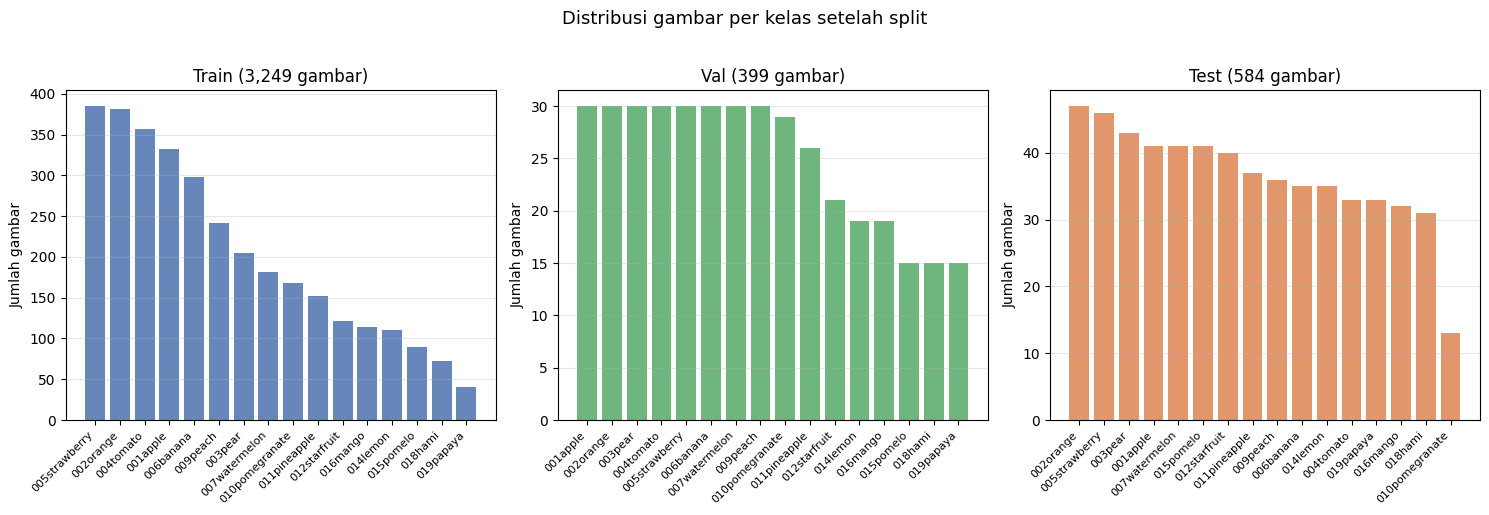

In [11]:
# Tahap 1E: Visualisasi distribusi split
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
subsets   = ["train", "val", "test"]
colors    = ["#4C72B0", "#55A868", "#DD8452"]

for ax, subset, color in zip(axes, subsets, colors):
    df_sub = df_verify[df_verify["subset"] == subset].sort_values("count", ascending=False)
    ax.bar(range(len(df_sub)), df_sub["count"], color=color, alpha=0.85)
    ax.set_xticks(range(len(df_sub)))
    ax.set_xticklabels(df_sub["folder_name"], rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{subset.capitalize()} ({df_sub['count'].sum():,} gambar)")
    ax.set_ylabel("Jumlah gambar")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Distribusi gambar per kelas setelah split", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [12]:
preparation_summary = {
    "timestamp"          : datetime.datetime.now().isoformat(),
    "random_seed"        : RANDOM_SEED,
    "phash_threshold"    : PHASH_THRESHOLD,
    "val_ratio"          : VAL_RATIO,
    "val_min_per_class"  : VAL_MIN_PER_CLASS,
    "val_max_per_class"  : VAL_MAX_PER_CLASS,
    "excluded_classes"   : sorted(EXCLUDED_CLASSES),
    "classes_kept"       : df_kept["folder_name"].tolist(),
    "total_raw"          : int(df_inventory["total_count"].sum()),
    "total_after_dedup"  : int((df_dedup["train_after"] + df_dedup["test_after"]).sum()),
    "total_removed_dedup": int(df_dedup["removed"].sum()),
    "split_totals"       : {
        "train": int(copy_stats["totals"]["train"]),
        "val"  : int(copy_stats["totals"]["val"]),
        "test" : int(copy_stats["totals"]["test"]),
    },
    "split_plan_per_class": df_split.to_dict(orient="records"),
    "output_dir"         : str(SPLIT_DIR),
    "exports_dir"        : str(EXPORTS_DIR),
}

summary_path = EXPORTS_DIR / "preparation_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(preparation_summary, f, indent=2, ensure_ascii=False)

print("[TAHAP 1E] Ekspor summary selesai.")
print(f"  Path: {summary_path}")
print()
print("  RINGKASAN PIPELINE NB01")
print(f"  Dataset raw          : {preparation_summary['total_raw']:,} gambar")
print(f"  Setelah deduplikasi  : {preparation_summary['total_after_dedup']:,} gambar")
print(f"  Duplikat dihapus     : {preparation_summary['total_removed_dedup']:,} gambar")
print(f"  Kelas di-keep        : {len(preparation_summary['classes_kept'])}")
print(f"  Kelas di-exclude     : {len(preparation_summary['excluded_classes'])}")
print()
print(f"  fruit_split/train    : {preparation_summary['split_totals']['train']:,} gambar")
print(f"  fruit_split/val      : {preparation_summary['split_totals']['val']:,} gambar")
print(f"  fruit_split/test     : {preparation_summary['split_totals']['test']:,} gambar")
print()
print(" NB01 selesai. Lanjutkan ke NB02 untuk filter per gambar.")


[TAHAP 1E] Ekspor summary selesai.
  Path: C:\Colorblind_correction\research\notebooks\01\output\preparation_summary.json

  RINGKASAN PIPELINE NB01
  Dataset raw          : 5,475 gambar
  Setelah deduplikasi  : 4,232 gambar
  Duplikat dihapus     : 498 gambar
  Kelas di-keep        : 16
  Kelas di-exclude     : 4

  fruit_split/train    : 3,249 gambar
  fruit_split/val      : 399 gambar
  fruit_split/test     : 584 gambar

 NB01 selesai. Lanjutkan ke NB02 untuk filter per gambar.
